# Experiment Comparison

Compares multiple trained runs side-by-side.  
Run each config first:
```bash
python -m transformer.train --config transformer/configs/config.yaml
python -m transformer.train --config transformer/config_k64.yaml
python -m transformer.train --config transformer/config_k128.yaml
python -m transformer.train --config transformer/config_dense.yaml
```

In [ ]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path(".").resolve().parent))

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import r2_score, mean_absolute_error

from transformer.dataset import make_splits
from transformer.model import CausalTTCTransformer
from transformer.train import evaluate, evaluate_nocontext

# ── Runs to compare ───────────────────────────────────────────────────────────
RUNS = [
    {"label": "K=32 sparse",    "ckpt": "../output/transformer_k32_sparse/best_model.pt"},
    {"label": "K=64 sparse",    "ckpt": "../output/transformer_k64_sparse/best_model.pt"},
    {"label": "K=128 sparse",   "ckpt": "../output/transformer_k128_sparse/best_model.pt"},
    {"label": "K=32 dense",     "ckpt": "../output/transformer_k32_dense/best_model.pt"},
    {"label": "K=32 per-frame", "ckpt": "../output/transformer_k32_nocontext_eval/best_model.pt"},
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

## 1 · Load checkpoints and evaluate on test set

In [ ]:
import torch.nn as nn

results = []   # list of dicts: label, val_r2, test_r2, test_mae, history_path

for run in RUNS:
    ckpt_path = Path(run["ckpt"])
    if not ckpt_path.exists():
        print(f"  SKIP {run['label']} — checkpoint not found: {ckpt_path}")
        continue

    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    cfg  = ckpt["cfg"]

    model = CausalTTCTransformer(
        d_input     = cfg["d_input"],
        d_model     = cfg["d_model"],
        n_heads     = cfg["n_heads"],
        n_layers    = cfg["n_layers"],
        d_ff        = cfg["d_ff"],
        dropout     = 0.0,
        K           = cfg["window_size"],
        predict_all = cfg.get("predict_all", False),
    ).to(DEVICE)
    model.load_state_dict(ckpt["model"])

    feat_cache = Path("../") / cfg["feat_cache"]
    hdf5_path  = Path("../") / cfg["hdf5_path"]
    _, _, test_ds = make_splits(feat_cache, hdf5_path, cfg)

    # Use pre-saved nocontext metrics if available; otherwise re-run normal evaluate
    if ckpt.get("test_r2_nc") is not None:
        test_r2  = ckpt["test_r2_nc"]
        test_mae = ckpt["test_mae_nc"]
        eval_tag = "no-context (pre-saved)"
    else:
        test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=0)
        criterion   = nn.MSELoss()
        _, test_r2, test_mae, _, _ = evaluate(model, test_loader, DEVICE, criterion)
        eval_tag = "rolling window"

    history_path = ckpt_path.parent / "history.npz"

    results.append({
        "label":        run["label"],
        "val_r2":       ckpt["val_r2"],
        "test_r2":      test_r2,
        "test_mae":     test_mae,
        "history_path": history_path,
        "window_size":  cfg["window_size"],
        "predict_all":  cfg.get("predict_all", False),
        "eval_tag":     eval_tag,
    })
    print(f"  {run['label']:18s}  val_R²={ckpt['val_r2']:.3f}  "
          f"test_R²={test_r2:.3f}  test_MAE={test_mae:.2f}s  [{eval_tag}]")

## 2 · Side-by-side bar chart

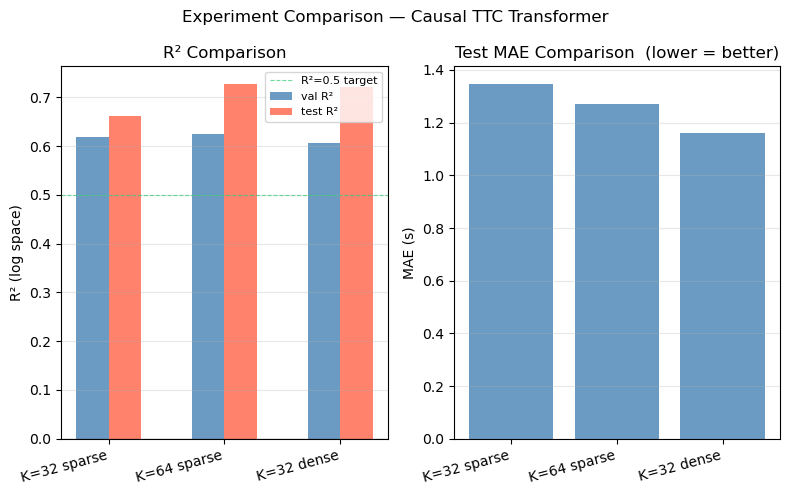

In [3]:
if not results:
    print("No completed runs found. Train at least one config first.")
else:
    labels    = [r["label"]    for r in results]
    test_r2s  = [r["test_r2"]  for r in results]
    test_maes = [r["test_mae"] for r in results]
    val_r2s   = [r["val_r2"]   for r in results]

    x = np.arange(len(results))
    w = 0.28

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(max(8, len(results) * 2.5), 5))

    ax1.bar(x - w/2, val_r2s,  w, label="val R²",  color="steelblue", alpha=0.8)
    ax1.bar(x + w/2, test_r2s, w, label="test R²", color="tomato",    alpha=0.8)
    ax1.axhline(0, color="k", lw=0.8)
    ax1.axhline(0.5, color="#2ecc71", lw=0.8, ls="--", alpha=0.7, label="R²=0.5 target")
    ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=15, ha="right")
    ax1.set_ylabel("R² (log space)"); ax1.set_title("R² Comparison")
    ax1.legend(fontsize=8); ax1.grid(True, axis="y", alpha=0.3)

    ax2.bar(x, test_maes, color="steelblue", alpha=0.8)
    ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=15, ha="right")
    ax2.set_ylabel("MAE (s)"); ax2.set_title("Test MAE Comparison  (lower = better)")
    ax2.grid(True, axis="y", alpha=0.3)

    plt.suptitle("Experiment Comparison — Causal TTC Transformer", fontsize=12)
    plt.tight_layout()
    plt.savefig("../output/transformer_k32_sparse/plots/comparison_bar.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## 3 · Training curves overlay

Requires `history.npz` saved alongside each checkpoint (written by `train.py` after the training loop).

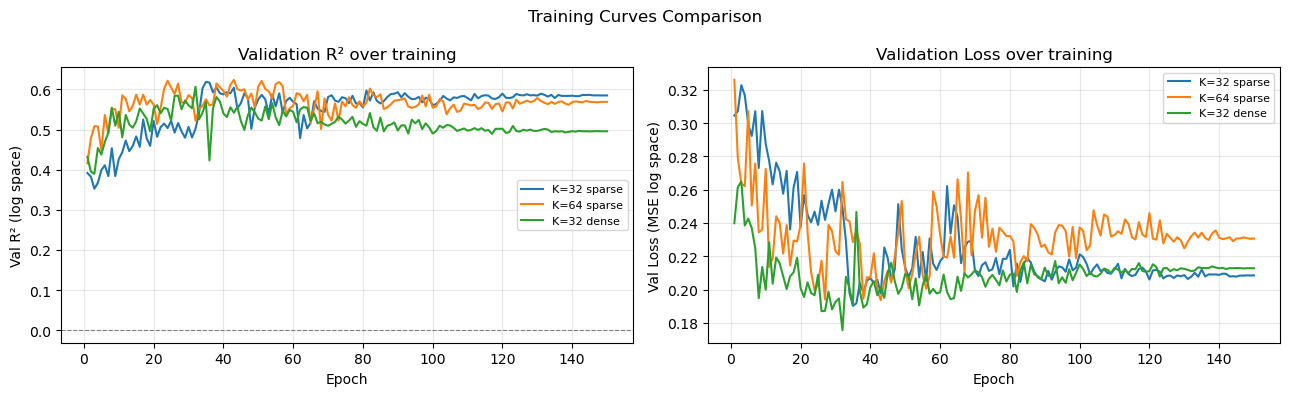

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for r in results:
    hp = r["history_path"]
    if not hp.exists():
        print(f"  history.npz missing for {r['label']} — retrain to generate")
        continue
    h = np.load(hp)
    ax1.plot(h["epoch"], h["val_r2"],   label=r["label"])
    ax2.plot(h["epoch"], h["val_loss"],  label=r["label"])

ax1.axhline(0, color="gray", lw=0.8, ls="--")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Val R² (log space)")
ax1.set_title("Validation R² over training"); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val Loss (MSE log space)")
ax2.set_title("Validation Loss over training"); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle("Training Curves Comparison", fontsize=12)
plt.tight_layout()
plt.show()